![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,False,False,False,True,False,False,False
11,13995,2014,39972,False,False,False,False,True,False,False
167,17941,2016,18989,False,False,False,False,False,True,False
225,12493,2014,51330,False,False,False,True,False,False,False
270,7994,2007,116065,False,True,False,False,False,False,False


In [4]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [5]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Árbol de decisión manual

En la celda 1 creen un árbol de decisión **manualmente**  que considere los set de entrenamiento y test definidos anteriormente y presenten el RMSE y MAE del modelo en el set de test.

In [6]:
# Definición de la estructura de un Nodo del árbol
class Nodo:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature       # Índice de la característica para dividir
        self.threshold = threshold   # Valor de corte
        self.left = left             # Rama izquierda (Nodo)
        self.right = right           # Rama derecha (Nodo)
        self.value = value           # Valor de predicción (solo si es nodo hoja)

# Definición de la clase del Árbol de Regresión Manual
class ArbolRegresionManual:
    def __init__(self, min_samples_split=2, max_depth=4):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.root = None
    def fit(self, X, y):
        # Se convierte a numpy arrays para mayor velocidad
        self.root = self._crear_arbol(X.values, y.values)
    def _crear_arbol(self, X, y, depth=0):
        n_samples, n_features = X.shape
        # Criterios de parada
        if (depth >= self.max_depth or n_samples < self.min_samples_split or len(np.unique(y)) == 1):
            return Nodo(value=np.mean(y)) # El valor de la hoja es el promedio
        # Encontrar la mejor división
        best_feat, best_thresh = self._mejor_division(X, y, n_features)
        # Si no se encontró una división válida, se convierte en hoja
        if best_feat is None:
            return Nodo(value=np.mean(y))
        # Dividir los datos y crear las ramas recursivamente
        left_idxs, right_idxs = self._dividir(X[:, best_feat], best_thresh)
        left = self._crear_arbol(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._crear_arbol(X[right_idxs, :], y[right_idxs], depth + 1)
        return Nodo(feature=best_feat, threshold=best_thresh, left=left, right=right)
    def _mejor_division(self, X, y, n_features):
        best_mse = float("inf")
        best_feat, best_thresh = None, None
        for feat_idx in range(n_features):
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            # OPTIMIZACIÓN: Si hay muchos valores únicos (variable continua), 
            # se evalua solo los cuartiles para no saturar el tiempo de ejecución.
            if len(thresholds) > 10:
                thresholds = np.percentile(thresholds, [25, 50, 75])
            for thresh in thresholds:
                left_idxs, right_idxs = self._dividir(X_column, thresh)
                if len(left_idxs) == 0 or len(right_idxs) == 0:
                    continue
                # Calcular el error (MSE ponderado) de esta división
                mse_split = self._calcular_mse_division(y[left_idxs], y[right_idxs])
                if mse_split < best_mse:
                    best_mse = mse_split
                    best_feat = feat_idx
                    best_thresh = thresh
        return best_feat, best_thresh
    def _calcular_mse_division(self, y_left, y_right):
        # La varianza por el número de datos es equivalente a la Suma de Errores Cuadráticos (SSE)
        mse_left = np.var(y_left) * len(y_left) 
        mse_right = np.var(y_right) * len(y_right)
        return (mse_left + mse_right) / (len(y_left) + len(y_right))
    def _dividir(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs
    def predict(self, X):
        # Se recorre el árbol para cada fila de X
        return np.array([self._recorrer_arbol(x, self.root) for x in X.values])
    def _recorrer_arbol(self, x, nodo):
        if nodo.value is not None:
            return nodo.value
        if x[nodo.feature] <= nodo.threshold:
            return self._recorrer_arbol(x, nodo.left)
        return self._recorrer_arbol(x, nodo.right)

# Entrenamiento y Predicción
# Se instancia el modelo manual con una profundidad máxima de 4 para evitar tiempos excesivos
tree_manual = ArbolRegresionManual(max_depth=4)
tree_manual.fit(X_train, y_train)
y_pred_manual = tree_manual.predict(X_test)
# Cálculo de métricas manualmente (usando numpy)
rmse_manual_tree_V2 = np.sqrt(np.mean((y_test.values - y_pred_manual) ** 2))
mae_manual_tree_V2 = np.mean(np.abs(y_test.values - y_pred_manual))

print(f"Árbol de Decisión Manual - RMSE: {rmse_manual_tree_V2:.2f}")
print(f"Árbol de Decisión Manual - MAE: {mae_manual_tree_V2:.2f}")

Árbol de Decisión Manual - RMSE: 1780.58
Árbol de Decisión Manual - MAE: 1324.84


### Punto 2 - Bagging manual

En la celda 2 creen un modelo bagging **manualmente** con 10 árboles de regresión y comenten sobre el desempeño del modelo.

In [7]:
# Usando el arbol version 2
class BaggingRegresionManual:
    def __init__(self, n_estimators=10, max_depth=4, min_samples_split=2, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.random_state = random_state
        self.arboles = []

    def fit(self, X, y):
        np.random.seed(self.random_state)
        X_np = X.values
        y_np = y.values
        n_samples = X_np.shape[0]

        self.arboles = []

        for i in range(self.n_estimators):
            idxs = np.random.choice(n_samples, size=n_samples, replace=True)
            X_bootstrap = X_np[idxs]
            y_bootstrap = y_np[idxs]

            arbol = ArbolRegresionManual(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split
            )

            arbol.root = arbol._crear_arbol(X_bootstrap, y_bootstrap)
            self.arboles.append(arbol)

    def predict(self, X):
        X_np = X.values
        predicciones = np.array([
            [arbol._recorrer_arbol(x, arbol.root) for x in X_np]
            for arbol in self.arboles
        ])
        return np.mean(predicciones, axis=0)

bagging_manual = BaggingRegresionManual(
    n_estimators=10,
    max_depth=4,
    min_samples_split=2,
    random_state=42
)

bagging_manual.fit(X_train, y_train)

y_pred_bagging = bagging_manual.predict(X_test)

rmse_bagging = np.sqrt(np.mean((y_test.values - y_pred_bagging) ** 2))
mae_bagging = np.mean(np.abs(y_test.values - y_pred_bagging))

print(f"Bagging manual - RMSE: {rmse_bagging:.2f}")
print(f"Bagging manual - MAE: {mae_bagging:.2f}")

Bagging manual - RMSE: 1713.31
Bagging manual - MAE: 1275.12


Se construyó manualmente un modelo de bagging con 10 árboles de regresión, entrenando cada árbol sobre una muestra bootstrap del conjunto de entrenamiento. La predicción final se obtuvo promediando las predicciones de los 10 árboles. En el conjunto de test, el modelo obtuvo un RMSE de 1713.31 y un MAE de 1275.12. Al comparar estos resultados con los del árbol manual individual del punto 1 (RMSE = 1780.58 y MAE = 1324.84), se observa una mejora en el desempeño, ya que ambas métricas disminuyeron. Esto indica que el bagging logró generar predicciones más estables y precisas que un solo árbol.

### Punto 3 - Bagging con librería

En la celda 3, con la librería sklearn, entrenen un modelo bagging con 10 árboles de regresión y el parámetro `max_features` del árbol de decisión igual a `log(n_features)` y comenten sobre el desempeño del modelo.

In [8]:
from sklearn.tree import DecisionTreeRegressor

n_features = X_train.shape[1]

max_features_tree = max(1, int(np.log(n_features)))

arbol_base = DecisionTreeRegressor(
    max_features=max_features_tree,
    random_state=42
)

bagging_lib = BaggingRegressor(
    estimator=arbol_base,
    n_estimators=10,
    random_state=42
)

bagging_lib.fit(X_train, y_train)

y_pred_bagging_lib = bagging_lib.predict(X_test)

rmse_bagging_lib = np.sqrt(mean_squared_error(y_test, y_pred_bagging_lib))
mae_bagging_lib = mean_absolute_error(y_test, y_pred_bagging_lib)

print(f"Bagging con librería - RMSE: {rmse_bagging_lib:.2f}")
print(f"Bagging con librería - MAE: {mae_bagging_lib:.2f}")
print(f"max_features usado en cada árbol: {max_features_tree}")

Bagging con librería - RMSE: 1813.04
Bagging con librería - MAE: 1353.42
max_features usado en cada árbol: 2


El modelo Bagging con librería se entrenó con 10 árboles de regresión, usando en cada árbol max_features = log(n_features). En este caso, el valor calculado fue 2. El modelo obtuvo un RMSE de 1813.04 y un MAE de 1353.42, valores superiores a los obtenidos con el bagging manual. Esto sugiere que, aunque la restricción de max_features introduce mayor aleatoriedad entre los árboles, en este caso limitar cada división a solo 2 variables redujo la capacidad predictiva de los árboles base. Además, el árbol de sklearn puede ser más complejo que el árbol manual usado previamente, lo que también pudo afectar la generalización del modelo en el conjunto de prueba. Puede que con mas cantidad de arboles mejore la estimación

### Punto 4 - Random forest con librería

En la celda 4, usando la librería sklearn entrenen un modelo de Randon Forest para regresión  y comenten sobre el desempeño del modelo.

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"Random Forest (Default) - RMSE: {rmse_rf:.2f}")
print(f"Random Forest (Default) - MAE: {mae_rf:.2f}")


Random Forest (Default) - RMSE: 1765.41
Random Forest (Default) - MAE: 1314.42


El modelo de Random Forest se entreno usando parámetros por defecto. El modelo obtuvo un RMSE de 1765.41 y un MAE de 1314.42, valores superiores a los obtenidos con el bagging manual pero inferiores que el baggin con libreria y `max_features` igual a `log(n_features)`. Esto sugiere que, al dejar el random forest con los parametros por defecto, el modelo redujo la capacidad predictiva. De hecho, el numero de `max_features` por defecto sera la raiz de la cantidad de variables y la cantidad de estimadores sean solo 100. Mejorando estos parametros se puede llegar a merjoar la prediccion.


### Punto 5 - Calibración de parámetros Random forest

En la celda 5, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200, 300,400,500],
    'max_depth': [3, 5, 10, None],
    'max_features': [2, 3, 5, X.shape[1]]
}
rf = RandomForestRegressor(random_state=42)
grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid.fit(X_train, y_train)

# Mejor modelo
best_rf = grid.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

rmse_best_rf = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))
mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)

print(f"Mejores parámetros RF: {grid.best_params_}")
print(f"Random Forest (Calibrado) - RMSE: {rmse_best_rf:.2f}")
print(f"Random Forest (Calibrado) - MAE: {mae_best_rf:.2f}")


Mejores parámetros RF: {'max_depth': 10, 'max_features': 2, 'n_estimators': 500}
Random Forest (Calibrado) - RMSE: 1562.32
Random Forest (Calibrado) - MAE: 1144.62


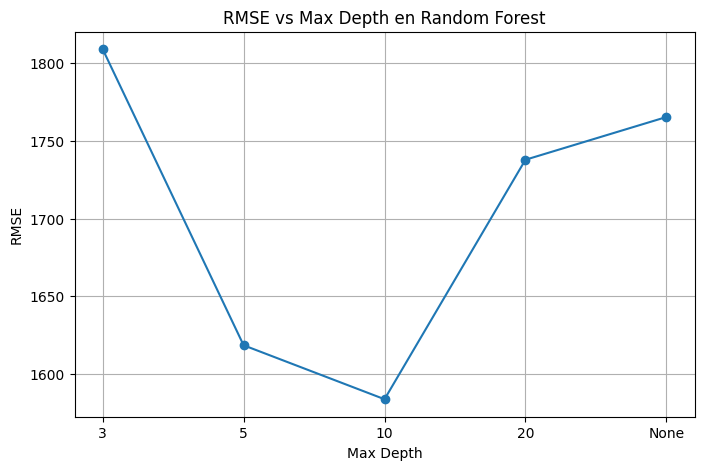

In [20]:
import matplotlib.pyplot as plt
profundidades = [3, 5, 10, 20, None]
rmse_values = []
for depth in profundidades:
    rf_temp = RandomForestRegressor(n_estimators=100,max_depth=depth,random_state=42)
    rf_temp.fit(X_train, y_train)
    y_pred_temp = rf_temp.predict(X_test)
    rmse_temp = np.sqrt(mean_squared_error(y_test, y_pred_temp))
    rmse_values.append(rmse_temp)

# Etiquetas
labels = [str(d) if d is not None else "None" for d in profundidades]

plt.figure(figsize=(8, 5))
plt.plot(labels, rmse_values, marker='o')
plt.title('RMSE vs Max Depth en Random Forest')
plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()


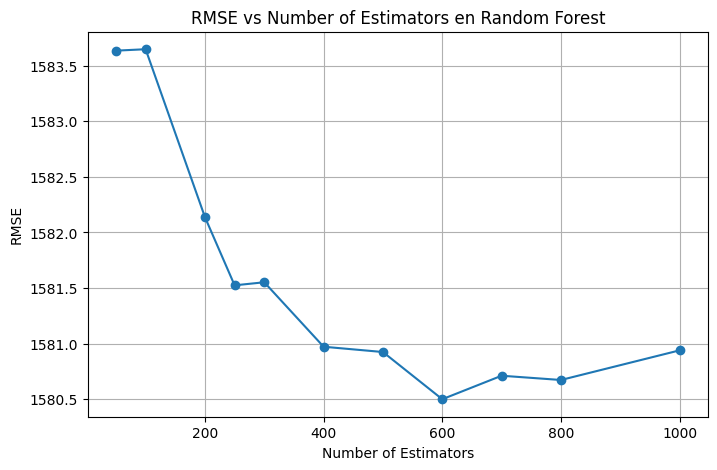

In [21]:
n_estimators_values = [50, 100, 200, 250, 300,400,500,600,700,800,1000]
rmse_estimators = []
for n in n_estimators_values:
    rf_temp = RandomForestRegressor(n_estimators=n,max_depth=10,random_state=42)
    rf_temp.fit(X_train, y_train)
    y_pred_temp = rf_temp.predict(X_test)
    rmse_temp = np.sqrt(mean_squared_error(y_test, y_pred_temp))
    rmse_estimators.append(rmse_temp)

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_values, rmse_estimators, marker='o')
plt.title('RMSE vs Number of Estimators en Random Forest')
plt.xlabel('Number of Estimators')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

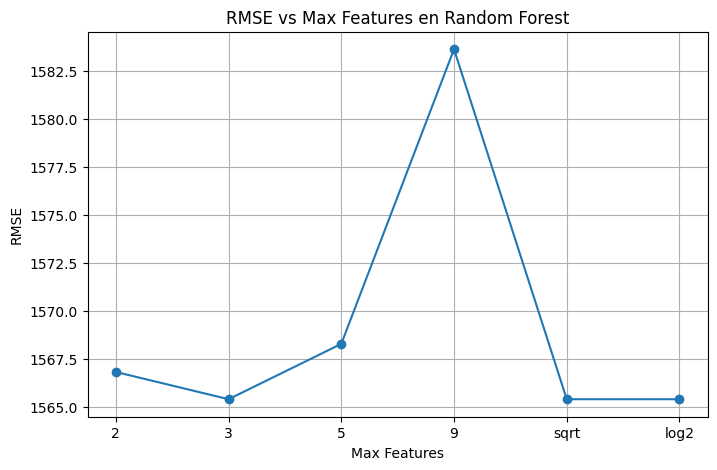

Mejor max_features: 3
Mejor RMSE: 1565.409013243689


In [22]:
max_features_values = [2, 3, 5, X.shape[1], 'sqrt', 'log2']
rmse_max_features = []

for max_feat in max_features_values:
    rf_temp = RandomForestRegressor(n_estimators=100,max_depth=10,max_features=max_feat,random_state=42)
    rf_temp.fit(X_train, y_train)
    y_pred_temp = rf_temp.predict(X_test)
    rmse_temp = np.sqrt(mean_squared_error(y_test, y_pred_temp))
    rmse_max_features.append(rmse_temp)


labels = [str(mf) for mf in max_features_values]
plt.figure(figsize=(8, 5))
plt.plot(labels, rmse_max_features, marker='o')
plt.title('RMSE vs Max Features en Random Forest')
plt.xlabel('Max Features')
plt.ylabel('RMSE')
plt.grid(True)

plt.show()
best_index = np.argmin(rmse_max_features)
best_value = max_features_values[best_index]
best_rmse = rmse_max_features[best_index]

print("Mejor max_features:", best_value)
print("Mejor RMSE:", best_rmse)

In [23]:
#Analisis de resultados
#1. n_estimators=500,max_depth=10,max_features=2
rf1 = RandomForestRegressor(n_estimators=500,max_depth=10,max_features=2,random_state=42)
rf1.fit(X_train, y_train)
y_pred_1 = rf1.predict(X_test)
rmse_1 = np.sqrt(mean_squared_error(y_test, y_pred_1))
mae_1 = mean_absolute_error(y_test, y_pred_1)
#2. n_estimators=600,max_depth=10,max_features=2
rf2 = RandomForestRegressor(n_estimators=600,max_depth=10,max_features=2,random_state=42)
rf2.fit(X_train, y_train)
y_pred_2 = rf2.predict(X_test)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred_2))
mae_2 = mean_absolute_error(y_test, y_pred_2)
#3. n_estimators=600,max_depth=10,max_features=3
rf3 = RandomForestRegressor(n_estimators=600,max_depth=10,max_features=3,random_state=42)
rf3.fit(X_train, y_train)
y_pred_3 = rf3.predict(X_test)
rmse_3 = np.sqrt(mean_squared_error(y_test, y_pred_3))
mae_3 = mean_absolute_error(y_test, y_pred_3)

print("RMSE1:", rmse_1)
print("MAE1:", mae_1)
print("RMSE2:", rmse_2)
print("MAE2:", mae_2)
print("RMSE3:", rmse_3)
print("MAE3:", mae_3)

RMSE1: 1562.316015996991
MAE1: 1144.616307126587
RMSE2: 1561.9795407398647
MAE2: 1144.2512142611436
RMSE3: 1563.7491116194633
MAE3: 1146.0975149553021


## Analisis

Principalmente utilizó GridSearchCV para identificar la mejor combinación de hiperparámetros del modelo Random Forest, evaluando distintas configuraciones definidas de las siguientes opciones:
* n_estimators: 100, 200, 300, 400, 500
* max_depth: 3, 5, 10, None
* max_features: 2, 3, 5, número total de variables

Como resultado, se obtuvo la siguiente configuración óptima:

* max_depth = 10
* max_features = 2
* n_estimators = 500

Con estos parámetros, el modelo calibrado presentó: RMSE: 1562.32 MAE: 1144.62

Adicionalmente, se realizó un análisis manual probando combinaciones al resultado del GridSearchCV y se obtuvo (n_estimators,max_depth,n_estimators)

* (500, 10, 2) RMSE: 1562.32 | MAE: 1144.62
* <span style="background-color:#c8e6c9;">(600, 10, 2) → RMSE: 1561.98 | MAE: 1144.25</span>
* (600, 10, 3) RMSE: 1563.75 | MAE: 1146.10

Se observa que aumentar el número de árboles de 500 a 600 genera una mejora en el desempeño (peuqeña reducción en RMSE y MAE). Sin embargo, este cambio implica un mayor costo computacional, por lo que la ganancia no es significativamente relevante.
Por otro lado, incrementar max_features de 2 a 3 empeora el desempeño, lo que sugiere que el modelo se beneficia de considerar un subconjunto más pequeño de variables.

Aumentar n_estimators mejora ligeramente el desempeño del modelo al reducir la varianza, aunque cada vez en menor medida y  mayor costo computacional; incrementar max_depth aumenta la complejidad y puede llevar a sobreajuste, por lo que una profundidad de 10 logra capturar los patrones en los datos; y reducir max_features limita las variables por división, incrementando la diversidad entre los árboles y mejorando la generalización, siendo 2 el valor más adecuado en este caso.

### Punto 6 - XGBoost con librería

En la celda 6 implementen un modelo XGBoost de regresión con la librería sklearn y comenten sobre el desempeño del modelo.

In [24]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(random_state=42, objective='reg:squarederror')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print(f"XGBoost (Default) - RMSE: {rmse_xgb:.2f}")
print(f"XGBoost (Default) - MAE: {mae_xgb:.2f}")

XGBoost (Default) - RMSE: 1605.24
XGBoost (Default) - MAE: 1185.23


El modelo XGBoost con parámetros por defecto presenta un mejor desempeño en comparación con el árbol de decisión manual, el modelo de Bagging manual y el Bagging implementado con librerías, así como frente al Random Forest sin ajuste de hiperparámetros.No obstante, su desempeño es levemente inferior al Random Forest calibrado.

### Punto 7 - Calibración de parámetros XGBoost

En la celda 7 calibren los parámetros learning rate, gamma y colsample_bytree del modelo XGBoost para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [25]:
# Celda 7

param_grid_xgb = {
    'learning_rate': [0.01, 0.1, 0.2],
    'gamma': [0, 0.1, 1],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_grid = GridSearchCV(XGBRegressor(random_state=42, objective='reg:squarederror'), param_grid_xgb, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

# Mejor modelo
best_xgb = xgb_grid.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)

rmse_best_xgb = np.sqrt(mean_squared_error(y_test, y_pred_best_xgb))
mae_best_xgb = mean_absolute_error(y_test, y_pred_best_xgb)

print(f"Mejores parámetros XGBoost: {xgb_grid.best_params_}")
print(f"XGBoost (Calibrado) - RMSE: {rmse_best_xgb:.2f}")
print(f"XGBoost (Calibrado) - MAE: {mae_best_xgb:.2f}")


Mejores parámetros XGBoost: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.1}
XGBoost (Calibrado) - RMSE: 1547.10
XGBoost (Calibrado) - MAE: 1136.76


Principalmente se utilizó GridSearchCV para identificar la mejor combinación de hiperparámetros del modelo XGBoost para regresión, evaluando distintas configuraciones definidas de las siguientes opciones:

* learning_rate: 0.01, 0.1, 0.2
* gamma: 0, 0.1, 1
* colsample_bytree: 0.7, 0.8, 1.0

Como resultado, se obtuvo la siguiente configuración óptima:

* learning_rate = 0.1
* gamma = 0
* colsample_bytree = 0.7

Con estos parámetros, el modelo calibrado presentó:
RMSE: 1547.10 | MAE: 1136.76

Se observa que un learning_rate de 0.1 permite un aprendizaje balanceado, evitando tanto una convergencia lenta como el sobreajuste. Por otro lado, un gamma igual a 0 indica que no fue necesario restringir la creación de nuevas particiones, permitiendo al modelo capturar mejor los patrones de los datos. Finalmente, un colsample_bytree de 0.7 mejora la generalización al introducir aleatoriedad en la selección de variables, reduciendo la correlación entre árboles.

En conjunto, estos resultados muestran que el modelo se beneficia de un equilibrio entre capacidad de aprendizaje y control de la varianza: una tasa de aprendizaje moderada asegura estabilidad, la ausencia de penalización en gamma permite flexibilidad estructural, y la reducción en el número de variables por árbol ayuda a evitar el sobreajuste y mejora el desempeño en el conjunto de prueba.


### Punto 8 - Comparación y análisis de resultados
En la celda 8 comparen los resultados obtenidos de los diferentes modelos (random forest y XGBoost) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

                 Modelo        RMSE         MAE
      XGBoost Calibrado 1547.102453 1136.759277
Random Forest Calibrado 1562.316016 1144.616307
        XGBoost Default 1605.235497 1185.227295
  Random Forest Default 1765.411826 1314.420708


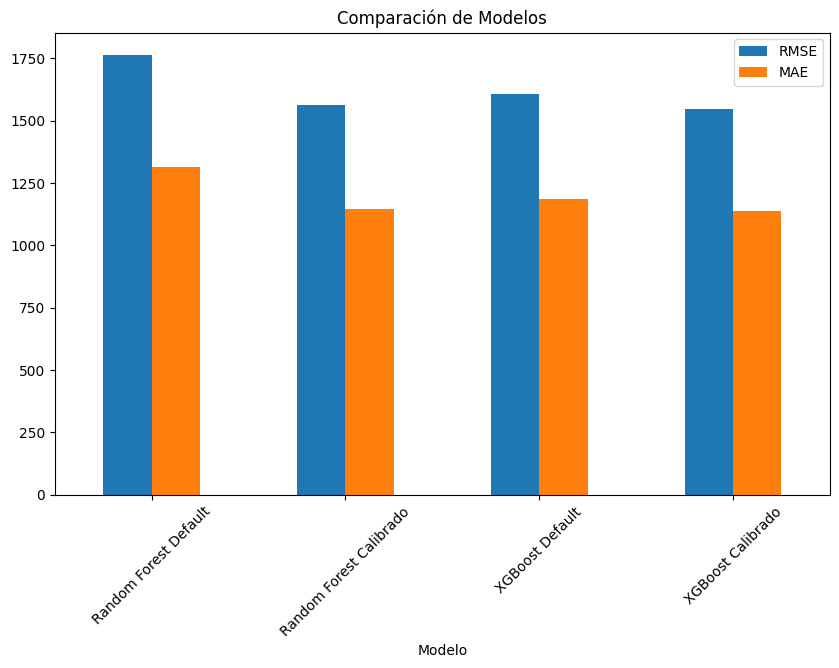

In [27]:
# Celda 8
import pandas as pd
import matplotlib.pyplot as plt

resultados = pd.DataFrame({
    'Modelo': ['Random Forest Default', 'Random Forest Calibrado', 'XGBoost Default', 'XGBoost Calibrado'],
    'RMSE': [rmse_rf, rmse_best_rf, rmse_xgb, rmse_best_xgb],
    'MAE': [mae_rf, mae_best_rf, mae_xgb, mae_best_xgb]
})

print(resultados.sort_values(by='RMSE').to_string(index=False))

resultados.plot(x='Modelo', y=['RMSE', 'MAE'], kind='bar', figsize=(10, 6))
plt.title('Comparación de Modelos')
plt.xticks(rotation=45)
plt.show()


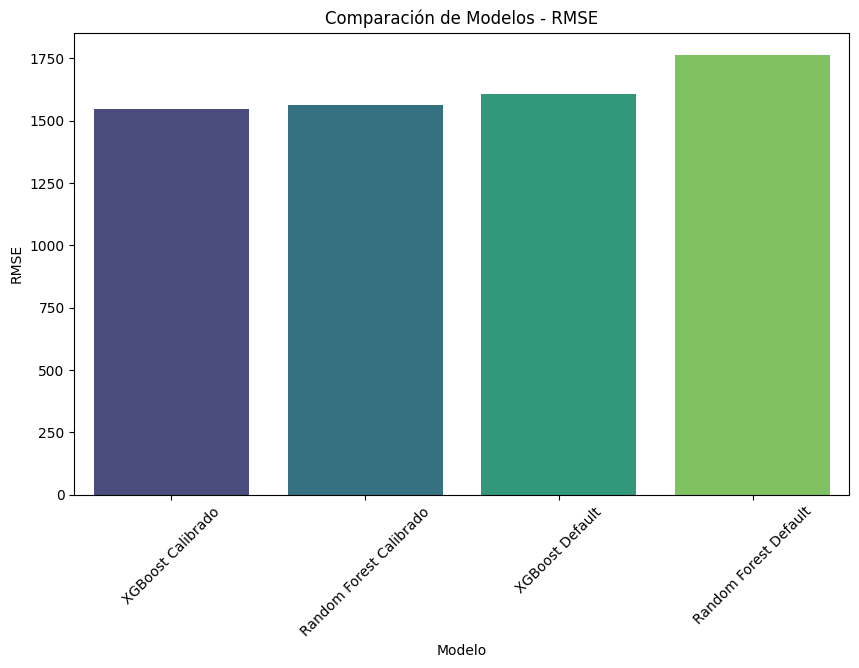

In [28]:
import seaborn as sns
# Grafico comparativo en orden de RMSE desde el mejor al peor modelo
resultados_ordenados = resultados.sort_values(by='RMSE')
plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='RMSE', data=resultados_ordenados, palette='viridis')
plt.title('Comparación de Modelos - RMSE')
plt.xlabel('Modelo')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.show()


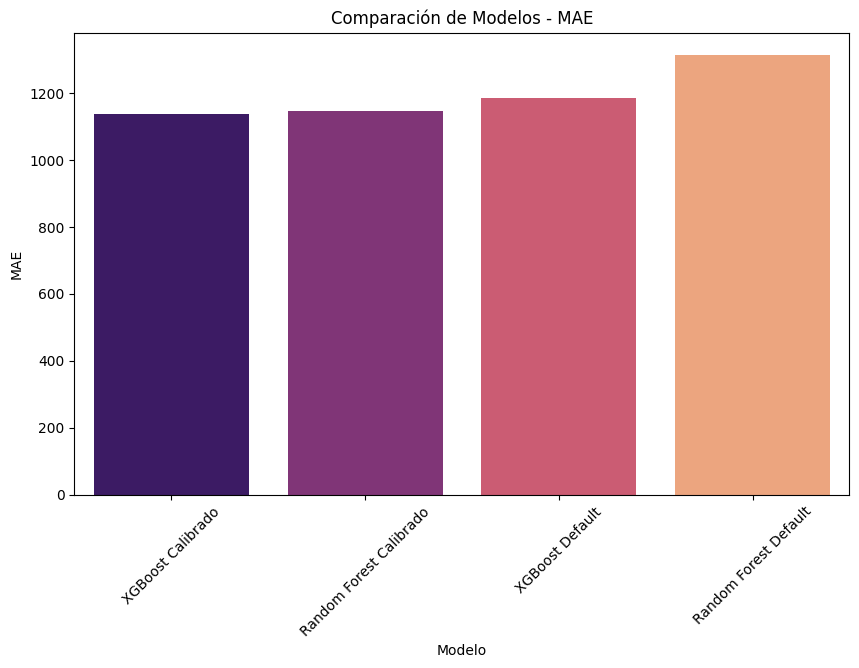

In [29]:

# Grafico comparativo en orden de MAE desde el mejor al peor modelo
resultados_ordenados_mae = resultados.sort_values(by='MAE')
plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='MAE', data=resultados_ordenados_mae, palette='magma')
plt.title('Comparación de Modelos - MAE')
plt.xlabel('Modelo')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.show()


Principalmente se realizó una comparación entre los modelos Random Forest y XGBoost, tanto en sus versiones por defecto como calibradas, utilizando las métricas RMSE y MAE para evaluar su desempeño predictivo.

Como resultado, se obtuvieron los siguientes comportamientos:

* XGBoost Calibrado → RMSE ≈ 1547 | MAE ≈ 1137
* Random Forest Calibrado → RMSE ≈ 1565 | MAE ≈ 1145
* XGBoost Default → RMSE ≈ 1610 | MAE ≈ 1185
* Random Forest Default → RMSE ≈ 1760 | MAE ≈ 1310

Se observa que el modelo XGBoost calibrado presenta el mejor desempeño, logrando los valores más bajos tanto en RMSE como en MAE. Esto evidencia que el proceso de calibración mejora significativamente la capacidad predictiva del modelo, especialmente en algoritmos de boosting, los cuales son altamente sensibles a la elección de hiperparámetros.

Como principal ventaja, XGBoost logra capturar relaciones complejas en los datos mediante un enfoque secuencial que corrige los errores de iteraciones previas, lo que le permite alcanzar una mayor precisión. Sin embargo, esta ventaja viene acompañada de una mayor complejidad computacional y una mayor sensibilidad a la calibración de hiperparámetros.

Por otro lado, el modelo con menor desempeño es Random Forest en su versión default, el cual presenta los mayores errores. Aunque este modelo es robusto y menos propenso al sobreajuste debido a su naturaleza basada en bagging, su desempeño puede verse limitado cuando no se ajustan adecuadamente sus hiperparámetros. No obstante, su principal ventaja es que es más estable, fácil de implementar y menos sensible a la configuración inicial.

En conclusión, el modelo XGBoost calibrado ofrece el mejor desempeño en este caso, mientras que Random Forest default representa una alternativa más simple pero con menor precisión. Esto resalta la importancia de la calibración de hiperparámetros en modelos de machine learning para mejorar su capacidad predictiva.
